In [1]:
import pickle as pkl
from rdkit import Chem
import numpy as np

sdf_data = pkl.load(open('data/bpa_sdf/bpa.pkl', 'rb'))
print(type(sdf_data), len(sdf_data))

for i, (smiles, mol) in enumerate(sdf_data):
    print(i, smiles)
    print(type(mol), len(mol), type(mol[0]))
    break


<class 'list'> 789
0 [H][O][P@]1(=[O])[O][C]2=[C]([C]3=[C]([H])[C]([C]([H])([H])[H])=[C]([H])[C]([C]([H])([H])[H])=[C]3[H])[C]([H])=[C]3[C]([H])=[C]([H])[C]([H])=[C]([H])[C]3=[C]2[C]2=[C]([O]1)[C]([C]1=[C]([H])[C]([C]([H])([H])[H])=[C]([H])[C]([C]([H])([H])[H])=[C]1[H])=[C]([H])[C]1=[C]([H])[C]([H])=[C]([H])[C]([H])=[C]12
<class 'list'> 1 <class 'rdkit.Chem.rdchem.Mol'>


[9.7322607e-01 2.1544522e-02 5.2109784e-03 1.8437042e-05]


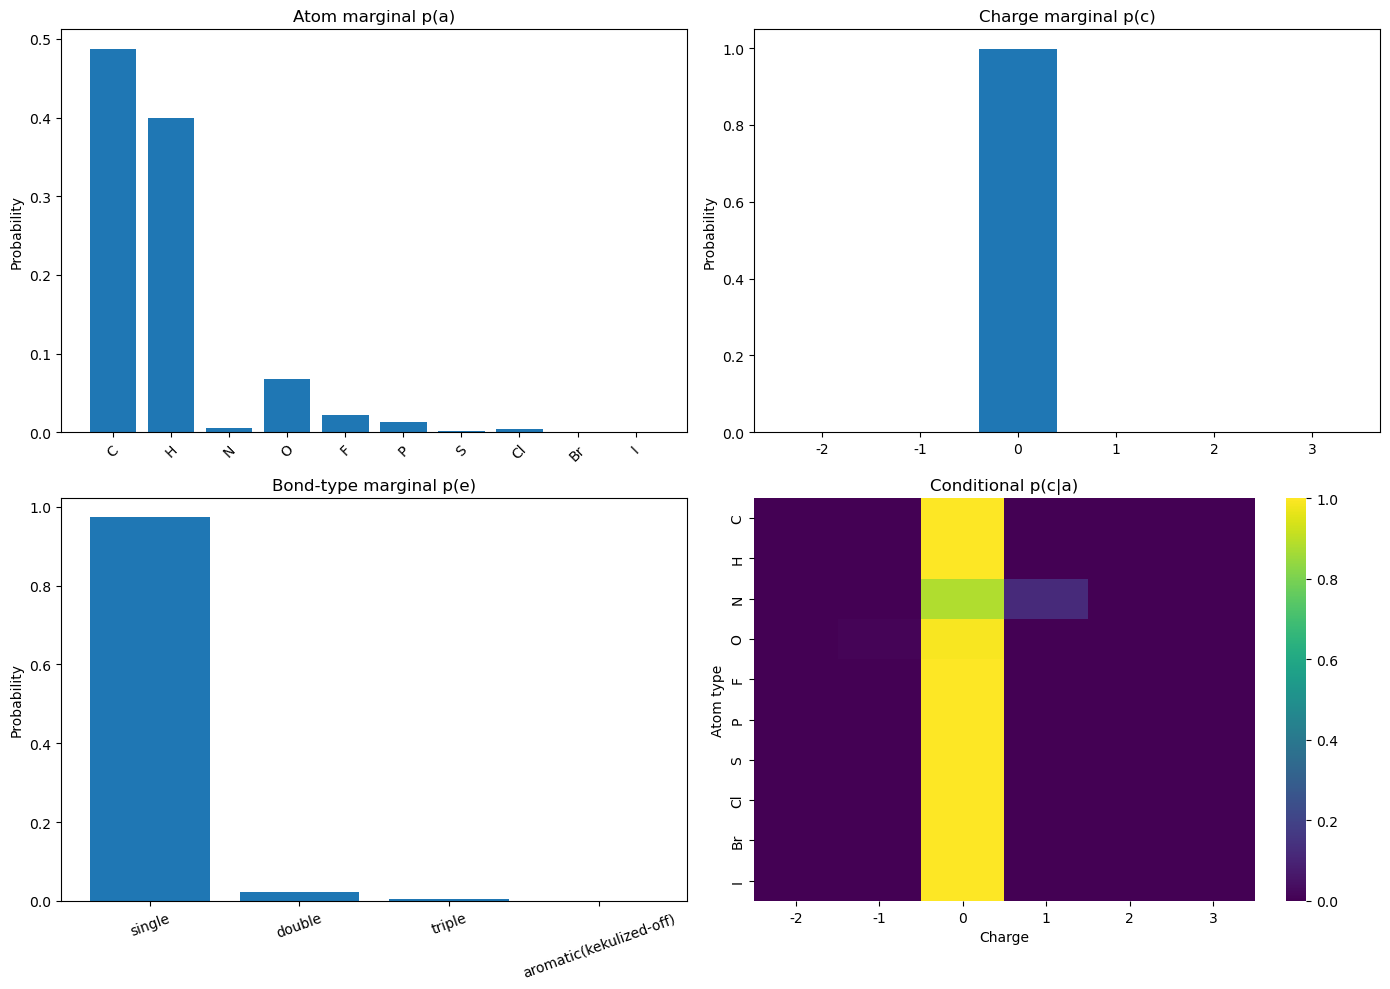

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# 1) Load distributions
pt_path = "data/bpa_full_kekulized_test/bpa_marginal_dists.pt"
p_a, p_c, p_e, p_c_given_a = torch.load(pt_path, map_location="cpu")

# convert to numpy
p_a = p_a.detach().cpu().numpy()
p_c = p_c.detach().cpu().numpy()
p_e = p_e.detach().cpu().numpy()
p_c_given_a = p_c_given_a.detach().cpu().numpy()

# 2) Load labels (atom map) from your config
cfg_path = "configs/flowmol3.yml"  # adjust if needed
with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)
atom_map = cfg["dataset"]["atom_map"]

# charge labels in process_geom.py are fixed to [-2, -1, 0, +1, +2, +3]
charge_labels = [-2, -1, 0, 1, 2, 3]

# bond labels (kekulized mode usually 4 types)
if len(p_e) == 4:
    bond_labels = ["single", "double", "triple", "aromatic(kekulized-off)"]
elif len(p_e) == 5:
    bond_labels = ["single", "double", "triple", "aromatic", "other"]
else:
    bond_labels = [f"bond_{i}" for i in range(len(p_e))]

# 3) Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# p(a)
axes[0, 0].bar(range(len(p_a)), p_a)
axes[0, 0].set_title("Atom marginal p(a)")
axes[0, 0].set_xticks(range(len(atom_map)))
axes[0, 0].set_xticklabels(atom_map, rotation=45)
axes[0, 0].set_ylabel("Probability")

# p(c)
axes[0, 1].bar(range(len(p_c)), p_c)
axes[0, 1].set_title("Charge marginal p(c)")
axes[0, 1].set_xticks(range(len(charge_labels)))
axes[0, 1].set_xticklabels(charge_labels)
axes[0, 1].set_ylabel("Probability")

# p(e)
axes[1, 0].bar(range(len(p_e)), p_e)
axes[1, 0].set_title("Bond-type marginal p(e)")
axes[1, 0].set_xticks(range(len(p_e)))
axes[1, 0].set_xticklabels(bond_labels, rotation=20)
axes[1, 0].set_ylabel("Probability")
print(p_e)

# p(c|a)
sns.heatmap(
    p_c_given_a,
    ax=axes[1, 1],
    cmap="viridis",
    cbar=True,
    xticklabels=charge_labels,
    yticklabels=atom_map
)
axes[1, 1].set_title("Conditional p(c|a)")
axes[1, 1].set_xlabel("Charge")
axes[1, 1].set_ylabel("Atom type")

plt.tight_layout()
plt.show()

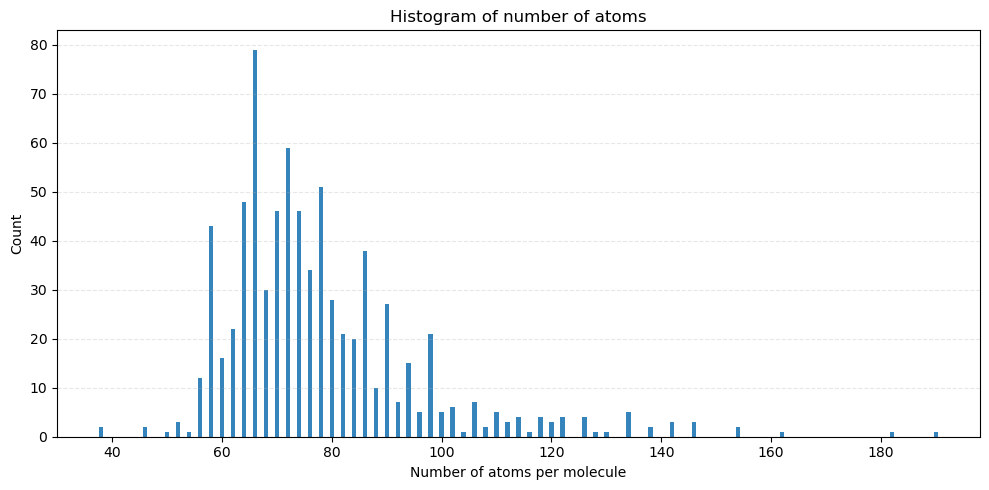

Total molecules: 756
Min atoms: 38, Max atoms: 190
Mean atoms per molecule: 77.85


In [3]:
import torch
import matplotlib.pyplot as plt

hist_path = "data/bpa_full_kekulized_test/bpa_n_atoms_histogram.pt"
n_atoms, counts = torch.load(hist_path, map_location="cpu")

x = n_atoms.detach().cpu().numpy()
y = counts.detach().cpu().numpy()

plt.figure(figsize=(10, 5))
plt.bar(x, y, width=0.8, alpha=0.9)
plt.xlabel("Number of atoms per molecule")
plt.ylabel("Count")
plt.title("Histogram of number of atoms")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total molecules: {int(y.sum())}")
print(f"Min atoms: {int(x.min())}, Max atoms: {int(x.max())}")
mean_atoms = (x * y).sum() / y.sum()
print(f"Mean atoms per molecule: {mean_atoms:.2f}")

In [4]:
import torch

pt_path = "data/bpa_aromatic/bpa_processed.pt"
data = torch.load(pt_path, map_location="cpu")

print("Top-level type:", type(data))
if isinstance(data, dict):
    print("\nKeys:")
    for k in data.keys():
        print(f"  - {k}")

    print("\nDetailed structure:")
    for k, v in data.items():
        print(f"\n[{k}]")
        print("  type:", type(v))

        if torch.is_tensor(v):
            print("  dtype:", v.dtype)
            print("  shape:", tuple(v.shape))
        elif isinstance(v, list):
            print("  len:", len(v))
            if len(v) > 0:
                print("  first item type:", type(v[0]))
                if torch.is_tensor(v[0]):
                    print("  first item tensor shape:", tuple(v[0].shape))
                elif isinstance(v[0], str):
                    print("  first item sample:", v[0][:120])
        else:
            print("  value preview:", str(v)[:200])
else:
    print("Loaded object is not a dict. Preview:", str(data)[:500])

Top-level type: <class 'dict'>

Keys:
  - smiles
  - positions
  - atom_types
  - atom_charges
  - bond_types
  - bond_idxs
  - node_idx_array
  - edge_idx_array

Detailed structure:

[smiles]
  type: <class 'list'>
  len: 789
  first item type: <class 'str'>
  first item sample: [H][O][P@]1(=[O])[O][C]2=[C]([C]3=[C]([H])[C]([C]([H])([H])[H])=[C]([H])[C]([C]([H])([H])[H])=[C]3[H])[C]([H])=[C]3[C]([

[positions]
  type: <class 'torch.Tensor'>
  dtype: torch.float32
  shape: (58856, 3)

[atom_types]
  type: <class 'torch.Tensor'>
  dtype: torch.bool
  shape: (58856, 10)

[atom_charges]
  type: <class 'torch.Tensor'>
  dtype: torch.int32
  shape: (58856,)

[bond_types]
  type: <class 'torch.Tensor'>
  dtype: torch.int32
  shape: (63896,)

[bond_idxs]
  type: <class 'torch.Tensor'>
  dtype: torch.int32
  shape: (63896, 2)

[node_idx_array]
  type: <class 'torch.Tensor'>
  dtype: torch.int32
  shape: (756, 2)

[edge_idx_array]
  type: <class 'torch.Tensor'>
  dtype: torch.int32
  shape: (75